In [3]:
# SHAP analysis, learning curves, hyperparameter tuning

import numpy as np
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, learning_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [4]:
# load data
df = pd.read_csv("../data/diabetes_data_clean_v2.csv")
features = [c for c in df.columns if c != "diabetes_class"]
X = df[features]
y = df["diabetes_class"].values

# same split as zirui_models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 416, Test: 104


In [15]:
# ---- SHAP values ----
# rf shap
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

# for binary classification, take class 1 (positive diabetes)
if len(shap_values.shape) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

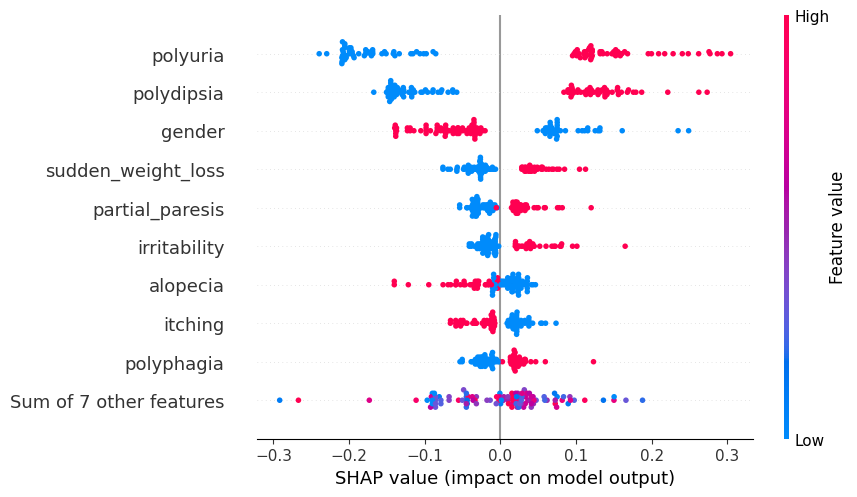

In [16]:
# beeswarm plot - shows per-sample feature impact
shap.plots.beeswarm(sv, show=True)

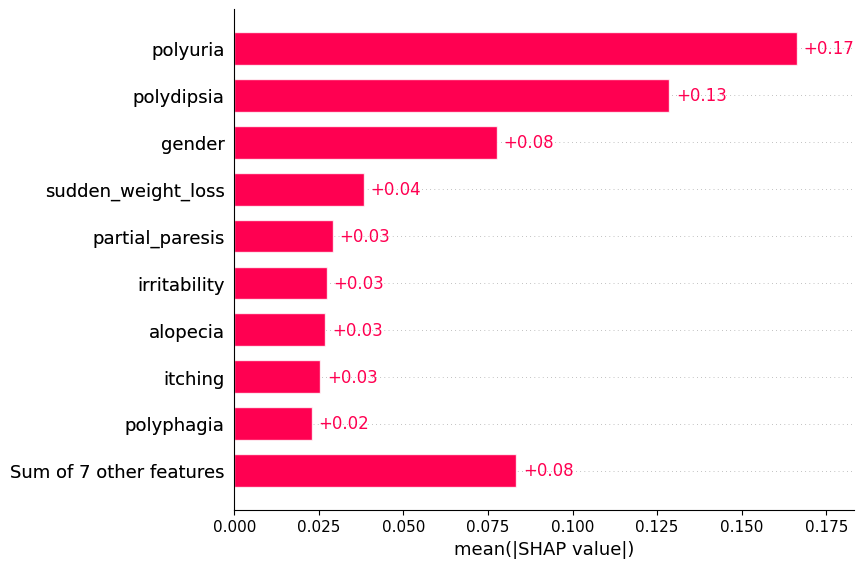

In [17]:
# bar plot - mean |SHAP| per feature
shap.plots.bar(sv, show=True)

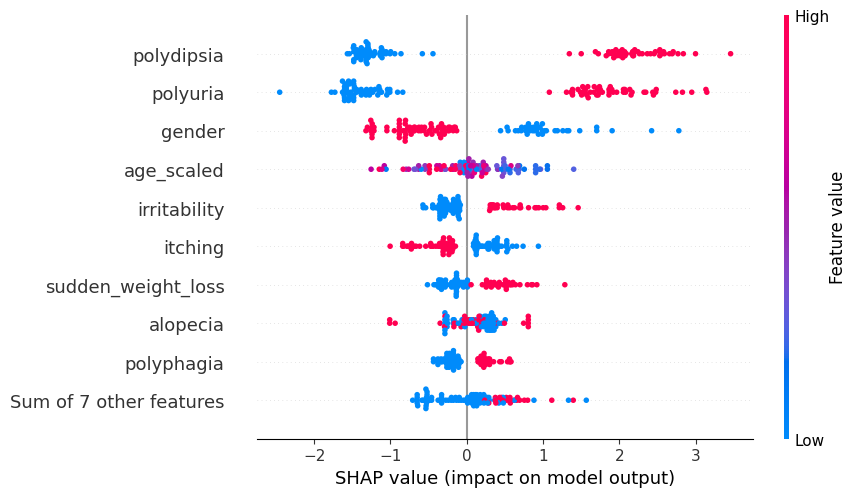

In [18]:
# xgb shap
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                     random_state=42, eval_metric="logloss")
xgb.fit(X_train, y_train)

explainer_xgb = shap.TreeExplainer(xgb)
sv_xgb = explainer_xgb(X_test)

shap.plots.beeswarm(sv_xgb, show=True)

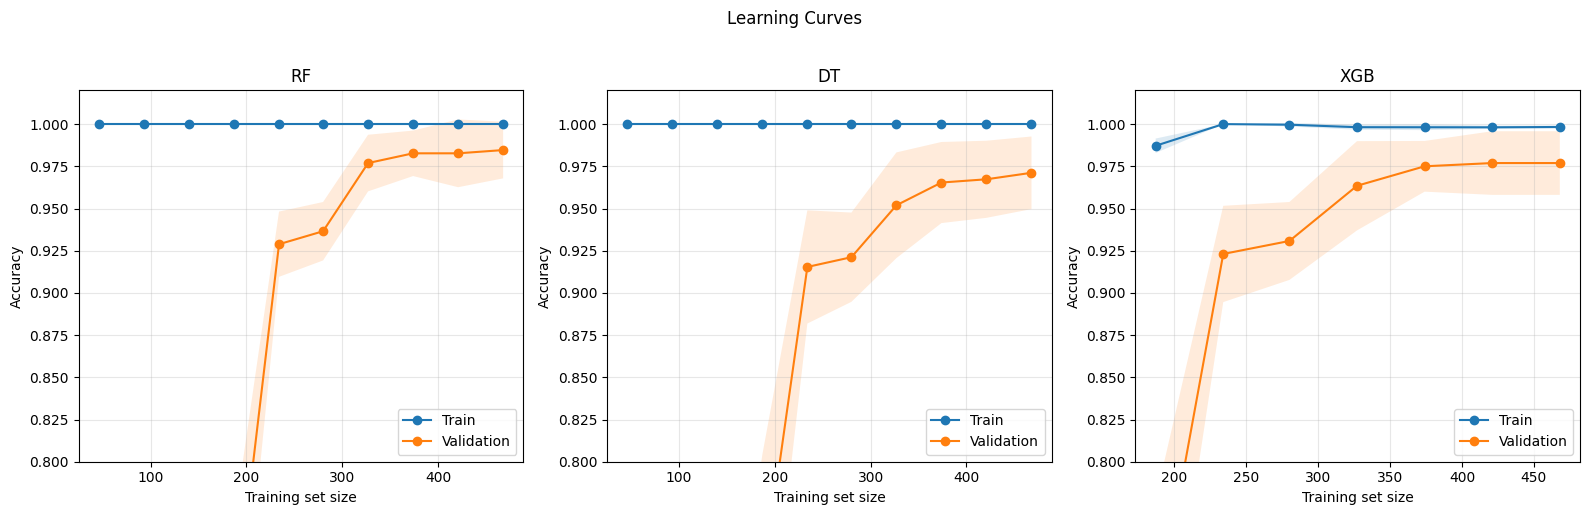

In [9]:
# ---- learning curves ----
models = {
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
    "XGB": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                         random_state=42, eval_metric="logloss"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy")

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", label="Train")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    ax.plot(train_sizes, val_mean, "o-", label="Validation")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    ax.set_title(name)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.8, 1.02)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning Curves", y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ---- hyperparameter tuning ----
# rf
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                       cv=cv, scoring="accuracy", n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
print(f"RF best params: {rf_grid.best_params_}")
print(f"RF best CV acc: {rf_grid.best_score_:.4f}")
print(f"RF test acc:    {accuracy_score(y_test, rf_best.predict(X_test)):.4f}")

RF best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
RF best CV acc: 0.9711
RF test acc:    0.9904


In [11]:
# dt
dt_params = {
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params,
                       cv=cv, scoring="accuracy", n_jobs=-1)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
print(f"DT best params: {dt_grid.best_params_}")
print(f"DT best CV acc: {dt_grid.best_score_:.4f}")
print(f"DT test acc:    {accuracy_score(y_test, dt_best.predict(X_test)):.4f}")

DT best params: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 2}
DT best CV acc: 0.9591
DT test acc:    0.9808


In [12]:
# xgb
xgb_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 6, 9],
    "learning_rate": [0.01, 0.1, 0.2],
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    xgb_params, cv=cv, scoring="accuracy", n_jobs=-1)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
print(f"XGB best params: {xgb_grid.best_params_}")
print(f"XGB best CV acc: {xgb_grid.best_score_:.4f}")
print(f"XGB test acc:    {accuracy_score(y_test, xgb_best.predict(X_test)):.4f}")

XGB best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
XGB best CV acc: 0.9664
XGB test acc:    0.9808


In [13]:
# ---- default vs tuned comparison ----
default_models = {
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
    "XGB": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                         random_state=42, eval_metric="logloss"),
}
rows = []
for name, def_model in default_models.items():
    def_model.fit(X_train, y_train)
    def_acc = accuracy_score(y_test, def_model.predict(X_test))
    tuned = {"RF": rf_best, "DT": dt_best, "XGB": xgb_best}[name]
    tuned_acc = accuracy_score(y_test, tuned.predict(X_test))
    rows.append({"Model": name, "Default": def_acc, "Tuned": tuned_acc,
                 "Diff": tuned_acc - def_acc})

pd.DataFrame(rows).set_index("Model").round(4)

,Default,Tuned,Diff
Model,,,
RF,0.9904,0.9904,0.0000
DT,0.9712,0.9808,0.0096
XGB,0.9904,0.9808,-0.0096
